# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [ ]:
from eclypse.placement.strategies import StaticStrategy
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from traffic_event import TrafficRoutingExecutionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge("Sensor1", "Cloud1", packet_size_bytes=1500, packets_per_tick=1, bandwidth=0)


packet_event = PacketGenerationEvent()

execution_event = TrafficRoutingExecutionEvent(tick_duration_s=0.001)
reporting_metric = TrafficRoutingMetric(tick_duration_s=0.001)

sim_config = SimulationConfig(
    seed=42,
    max_steps=101, 
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="csv", 
    report_backend="pandas",
    remote=False
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
[OSPF] NumPy routing matrix (6x6) recalculated.
2. Setting up Application (Video Stream)...
Added edge flow Sensor1->Cloud1: 1 pkt/tick, size 1500B
3. Initializing Simulation...
[DEBUG GEN] Tick 1: App 'VideoApp' has generated 1 packets.
11:48:43.754 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results | remote=False | step_every_ms=500 | max_steps=101 | seed=42 | report_format=csv | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
11:48:43.755 | ECLYPSE | Simulation - Simulation started.
11:48:43.758 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
11:48:43.759 | ECLYPSE | Simulation - Simulation step | step=1
[DEBUG GEN] Tick 2: App 'VideoApp' has generated 1 packets.11:48:44.259 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}

1

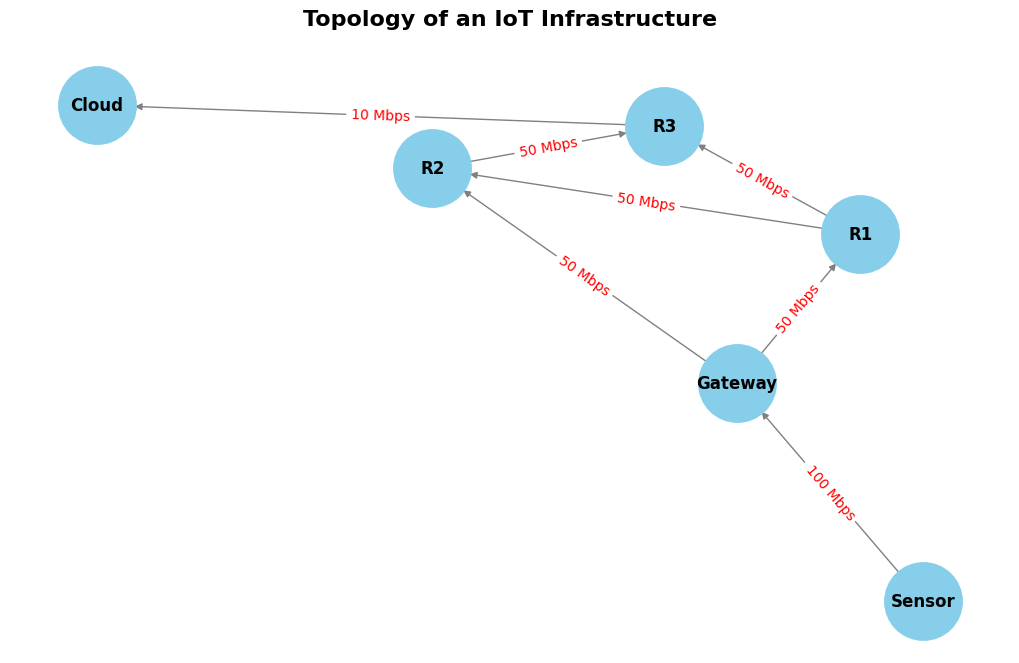

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

# Calculate the positions of the nodes using the spring layout algorithm 
pos = nx.spring_layout(infra, seed=42) 

# Draw the network with custom styling
nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue', 
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off') # Hide axes for better visualization
plt.show()

In [4]:
import pandas as pd
# Load the CSV using the correct column names 
csv_path = "./results/csv/application.csv" # Inserisci il percorso corretto se necessario
columns = [
    'timestamp', 'event_type', 'n_event', 
    'callback_id', 'application_id', 'metric_name', 'metric_value'
]
df_raw = pd.read_csv(csv_path, names=columns, header=0)

# Filter the data and process the column names to extract packet ID, hop number, and metric type
df_hops_raw = df_raw[df_raw['metric_name'].astype(str).str.contains("_Hop_")].copy()
extracted = df_hops_raw['metric_name'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops_raw['id pkt'] = extracted[0].astype(int)
df_hops_raw['hop number'] = extracted[1].astype(int)
df_hops_raw['field'] = extracted[2]

# Pivot to create the compact table (remove timestamp from the index to avoid NaNs)
df_table = df_hops_raw.pivot_table(
    index=['application_id', 'id pkt', 'hop number'],
    columns='field',
    values='metric_value',
    aggfunc='first'
).reset_index()

# Ensure that the fields we want to print are numeric and not text
df_table['arrival_at_next'] = pd.to_numeric(df_table['arrival_at_next'])
df_table['queue_length'] = pd.to_numeric(df_table['queue_length']).fillna(0).astype(int)

# Reconstruct the list of events for the print
all_events = []
for index, row in df_table.iterrows():
    # Use the dictionary to create a structured event for each row
    all_events.append({
        'time': row['arrival_at_next'],
        'packet_id': row['id pkt'],
        'event': f"Link: {row['hop']:^17} | Status: FINISHED | Queue: {row['queue_length']:>2} pkts"
    })

# Order everything by time 
all_events_sorted = sorted(all_events, key=lambda x: x['time'])

print("HOP CHRONOLOGICAL LOG")
for ev in all_events_sorted:
    print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")

HOP CHRONOLOGICAL LOG
[  0.001182s] | Packet: 1     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001548s] | Packet: 1     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001777s] | Packet: 1     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.002118s] | Packet: 2     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.002464s] | Packet: 2     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.003060s] | Packet: 2     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.003147s] | Packet: 3     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.003324s] | Packet: 3     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.003893s] | Packet: 3     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.004329s] | Packet: 4     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.004742s] | Packet: 4     | Link:    Gateway->R1    | 

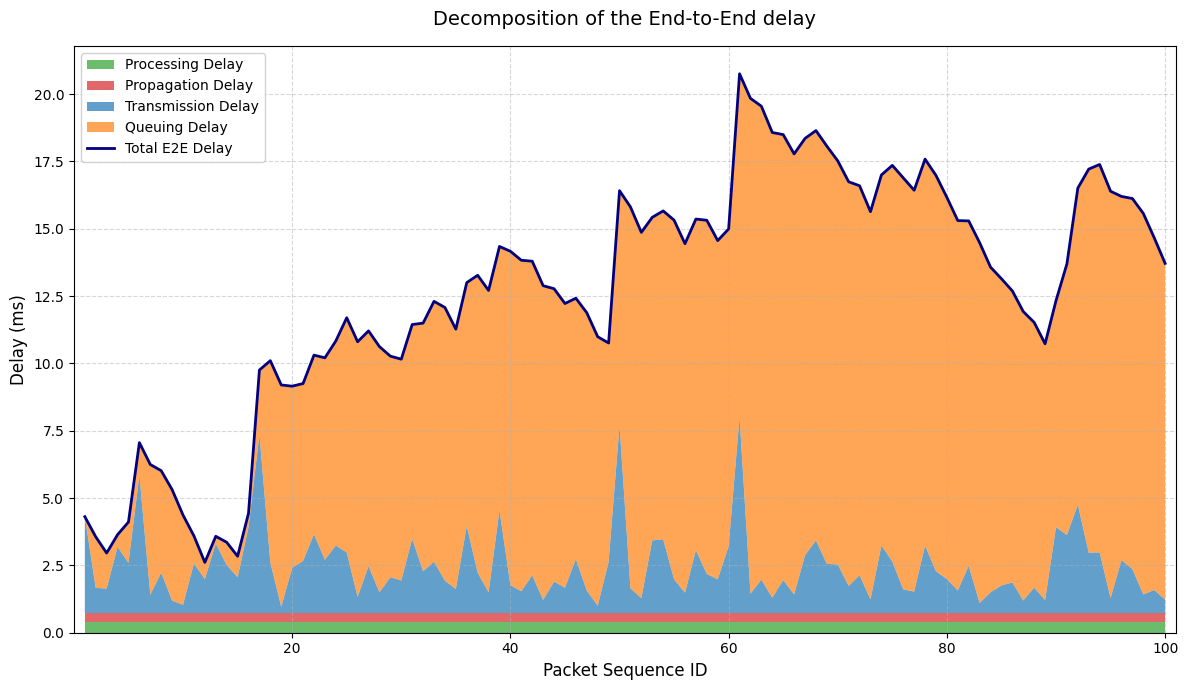


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 0.50 ms
- Queuing:      12.48 ms
--------------------------------
= TOTAL:        13.72 ms


In [5]:
import pandas as pd
import matplotlib.pyplot as plt


csv_path = "./results/csv/application.csv"
columns = ['timestamp', 'event_type', 'n_event', 'callback_id', 'application_id', 'metric_name', 'metric_value']
df_raw = pd.read_csv(csv_path, names=columns, header=0)

class DummyHop:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, v)

packets = {}
for _, row in df_raw.iterrows():
    metric = str(row['metric_name'])
    val = row['metric_value']
    
    if not metric.startswith("pkt_"):
        continue 
    tokens = metric.split('_')
    pkt_id = int(tokens[1])
    
    if pkt_id not in packets:
        packets[pkt_id] = {'Packet_ID': pkt_id, 'Hops': [], '_hops_temp': {}}
        
    if "Total_Delay_ms" in metric:
        packets[pkt_id]['Total_Delay_ms'] = float(val)
        
    elif "_Hop_" in metric:
        hop_num = int(tokens[3])
        field = "_".join(tokens[4:])
        if hop_num not in packets[pkt_id]['_hops_temp']:
            packets[pkt_id]['_hops_temp'][hop_num] = {}
            
        try:
            packets[pkt_id]['_hops_temp'][hop_num][field] = float(val)
        except ValueError:
            packets[pkt_id]['_hops_temp'][hop_num][field] = val

for pkt_id, data in packets.items():
    ordered_hops = [data['_hops_temp'][k] for k in sorted(data['_hops_temp'].keys())]
    data['Hops'] = [DummyHop(h) for h in ordered_hops]
    del data['_hops_temp']

df_results = pd.DataFrame(list(packets.values()))
df_results = df_results.sort_values('Packet_ID').reset_index(drop=True)


# Helper function to sum a specific metric across all hops of a packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(getattr(hop, metric_name, 0.0) for hop in hops_list)

df = df_results 

# Find automatically the name of the hops column
hops = 'Hops' if 'Hops' in df.columns else 'Hops_Details'

# Creation of new columns with the sum of each metric across all hops
df['Total_Proc_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# Creation of the graph
plt.figure(figsize=(12, 7))

# Create the stackplot for the breakdown of delays
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# Upper line to mark the Total E2E Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final print to show the breakdown of the last packet
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")

# Failure recovery

In [6]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [ ]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingExecutionEvent
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from fault_injection import FaultInjectionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge("Sensor1", "Cloud1", packet_size_bytes=1500, packets_per_tick=1, bandwidth=0)

packet_event = PacketGenerationEvent()
traffic_event = TrafficRoutingExecutionEvent(tick_duration_s=0.0005)
traffic_metric = TrafficRoutingMetric(tick_duration_s=0.0005)


sim_config = SimulationConfig(
        seed=42,
        max_steps=101,
        step_every_ms=1000,
        path= "./results-20260511_160749",
        events=[packet_event, traffic_event, traffic_metric, FaultInjectionEvent], 
        include_default_metrics=False,
        report_format="csv", 
        report_backend="pandas",
        
        remote=False
    )

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
[OSPF] NumPy routing matrix (6x6) recalculated.
2. Setting up Application (Video Stream)...
Added edge flow Sensor1->Cloud1: 1 pkt/tick, size 1500B
3. Initializing Simulation...
[DEBUG GEN] Tick 1: App 'VideoApp' has generated 1 packets.
11:51:42.733 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results-20260511_160749 | remote=False | step_every_ms=1000 | max_steps=101 | seed=42 | report_format=csv | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
11:51:42.735 | ECLYPSE | Simulation - Simulation started.
11:51:42.740 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
11:51:42.740 | ECLYPSE | Simulation - Simulation step | step=1
[DEBUG GEN] Tick 2: App 'VideoApp' has generated 1 packets.
11:51:43.741 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cl

In [9]:
import pandas as pd
# Load the CSV using the correct column names 
csv_path = "./results-20260511_160749/csv/application.csv" 
columns = [
    'timestamp', 'event_type', 'n_event', 
    'callback_id', 'application_id', 'metric_name', 'metric_value'
]
df_raw = pd.read_csv(csv_path, names=columns, header=0)

# Filter the data and process the column names to extract packet ID, hop number, and metric type
df_hops_raw = df_raw[df_raw['metric_name'].astype(str).str.contains("_Hop_")].copy()
extracted = df_hops_raw['metric_name'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops_raw['id pkt'] = extracted[0].astype(int)
df_hops_raw['hop number'] = extracted[1].astype(int)
df_hops_raw['field'] = extracted[2]

# Pivot to create the compact table (remove timestamp from the index to avoid NaNs)
df_table = df_hops_raw.pivot_table(
    index=['application_id', 'id pkt', 'hop number'],
    columns='field',
    values='metric_value',
    aggfunc='first'
).reset_index()

# Ensure that the fields we want to print are numeric and not text
df_table['arrival_at_next'] = pd.to_numeric(df_table['arrival_at_next'])
df_table['queue_length'] = pd.to_numeric(df_table['queue_length']).fillna(0).astype(int)

# Reconstruct the list of events for the print
all_events = []
for index, row in df_table.iterrows():
    # Use the dictionary to create a structured event for each row
    all_events.append({
        'time': row['arrival_at_next'],
        'packet_id': row['id pkt'],
        'event': f"Link: {row['hop']:^17} | Status: FINISHED | Queue: {row['queue_length']:>2} pkts"
    })

# Order everything by time 
all_events_sorted = sorted(all_events, key=lambda x: x['time'])

print("HOP CHRONOLOGICAL LOG")
for ev in all_events_sorted:
    print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")

HOP CHRONOLOGICAL LOG
[  0.000682s] | Packet: 1     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001048s] | Packet: 1     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001118s] | Packet: 2     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001277s] | Packet: 1     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.001464s] | Packet: 2     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001647s] | Packet: 3     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001824s] | Packet: 3     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.002060s] | Packet: 2     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.002329s] | Packet: 4     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.002479s] | Packet: 3     | Link:      R1->R3       | Status: FINISHED | Queue:  1 pkts
[  0.002704s] | Packet: 5     | Link:  Sensor->Gateway  | 

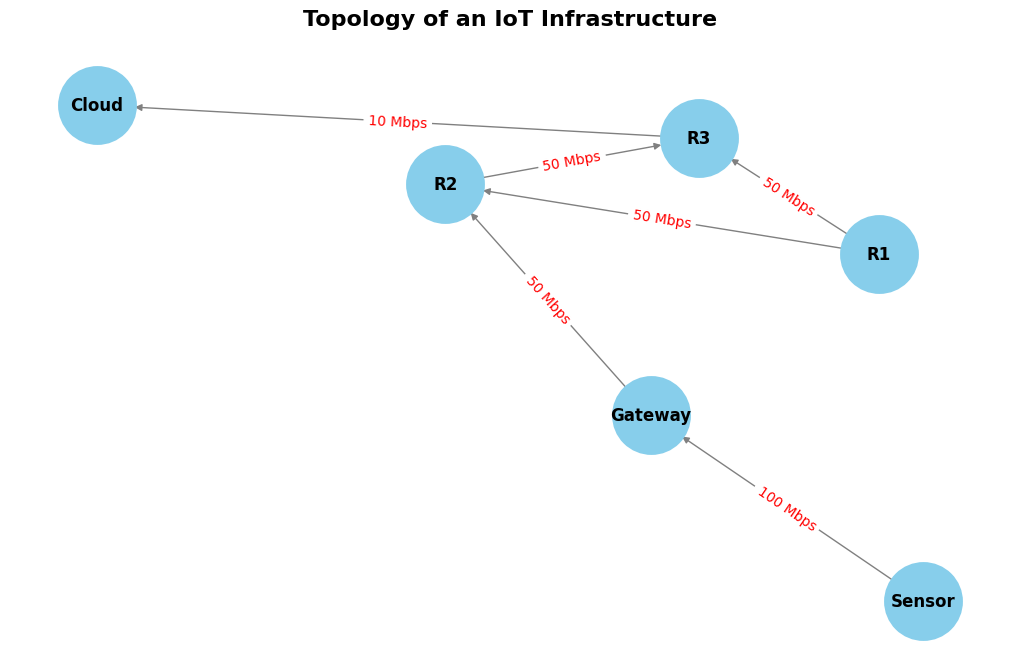

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(infra, seed=42) 


nx.draw(
    infra, 
    pos, 
    with_labels=True, 
    node_color='skyblue', 
    node_size=3000, 
    font_size=12, 
    font_weight='bold', 
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

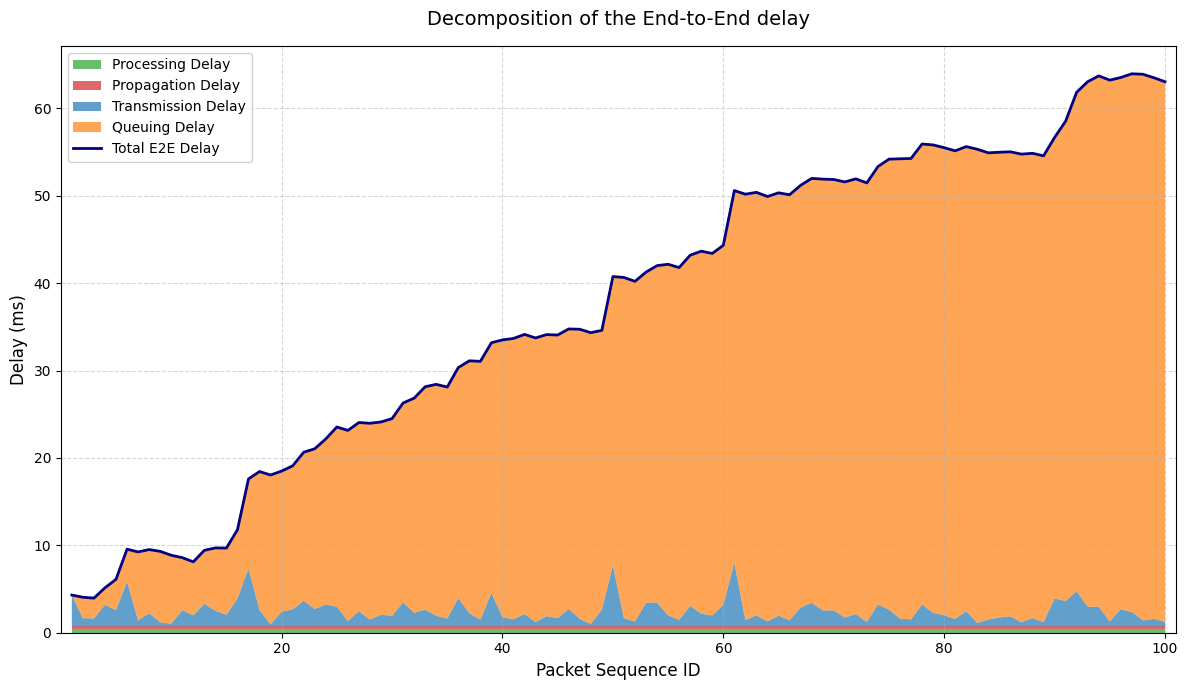


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 0.50 ms
- Queuing:      61.83 ms
--------------------------------
= TOTAL:        63.06 ms


In [11]:
import pandas as pd
import matplotlib.pyplot as plt


csv_path = "./results-20260511_160749/csv/application.csv"
columns = ['timestamp', 'event_type', 'n_event', 'callback_id', 'application_id', 'metric_name', 'metric_value']
df_raw = pd.read_csv(csv_path, names=columns, header=0)


class DummyHop:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, v)

packets = {}
for _, row in df_raw.iterrows():
    metric = str(row['metric_name'])
    val = row['metric_value']
    
    if not metric.startswith("pkt_"):
        continue 
    tokens = metric.split('_')
    pkt_id = int(tokens[1])
    
    if pkt_id not in packets:
        packets[pkt_id] = {'Packet_ID': pkt_id, 'Hops': [], '_hops_temp': {}}
        
    if "Total_Delay_ms" in metric:
        packets[pkt_id]['Total_Delay_ms'] = float(val)
        
    elif "_Hop_" in metric:
        hop_num = int(tokens[3])
        field = "_".join(tokens[4:])
        if hop_num not in packets[pkt_id]['_hops_temp']:
            packets[pkt_id]['_hops_temp'][hop_num] = {}
            
        try:
            packets[pkt_id]['_hops_temp'][hop_num][field] = float(val)
        except ValueError:
            packets[pkt_id]['_hops_temp'][hop_num][field] = val

for pkt_id, data in packets.items():
    ordered_hops = [data['_hops_temp'][k] for k in sorted(data['_hops_temp'].keys())]
    data['Hops'] = [DummyHop(h) for h in ordered_hops]
    del data['_hops_temp']

df_results = pd.DataFrame(list(packets.values()))
df_results = df_results.sort_values('Packet_ID').reset_index(drop=True)


# Helper function to sum a specific metric across all hops of a packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(getattr(hop, metric_name, 0.0) for hop in hops_list)

df = df_results 

# Find automatically the name of the hops column
hops = 'Hops' if 'Hops' in df.columns else 'Hops_Details'

# Creation of new columns with the sum of each metric across all hops
df['Total_Proc_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# Creation of the graph
plt.figure(figsize=(12, 7))

# Create the stackplot for the breakdown of delays
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# Upper line to mark the Total E2E Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final print to show the breakdown of the last packet
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")